# 🦾 Inverse Kinematics Planar Robot 3-DOF
## Pendekatan Machine Learning, Deep Learning
---
> **Nama:** [SISTRA AMANDA SINAGA]  
> **NIM:** [42223O1O11]  
# Praktikum IK Robot 3-DOF
---
> **Prasyarat:** Python, NumPy, dasar ML & Neural Network  
> **Tools:** `numpy`, `matplotlib`, `scikit-learn`, `torch`, `gymnasium`, `stable-baselines3`


---
## 📖 Bagian 1: Pengantar Forward & Inverse Kinematics

### Apa itu Kinematika Robot?

**Forward Kinematics (FK):** Diberikan sudut sendi → hitung posisi end-effector  
- Mudah ✅, solusi **unik**

**Inverse Kinematics (IK):** Diberikan posisi target → hitung sudut sendi  
- Sulit ⚠️, solusi bisa **banyak** atau **tidak ada**

### Robot Planar 3-DOF
- 3 link (lengan): `L1=0.5m`, `L2=0.4m`, `L3=0.3m`
- 3 sendi (joint): `θ1, θ2, θ3` (dalam radian)
- End-effector: ujung lengan ke-3

### Persamaan FK:
```
x = L1·cos(θ1) + L2·cos(θ1+θ2) + L3·cos(θ1+θ2+θ3)
y = L1·sin(θ1) + L2·sin(θ1+θ2) + L3·sin(θ1+θ2+θ3)
```

### Pendekatan IK dengan AI yang Digunakan:
| Pendekatan | Metode | Kelebihan |
|------------|--------|-----------|
| **ML** | Extra Trees, Ridge, MLP Regressor | Cepat, variatif, mudah dibandingkan |
| **DL** | Neural Network (PyTorch IKNet) | Akurat, generalisasi baik |


In [1]:
# Install dependencies (jalankan sekali)
!pip install gymnasium stable-baselines3 scikit-learn torch matplotlib numpy tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 39.4 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0
✅ Library siap!


In [2]:
# ─── Konfigurasi Robot ───────────────────────────────────────────────
L1, L2, L3 = 0.5, 0.4, 0.3      # Panjang link (meter)
LINK_LENGTHS = np.array([L1, L2, L3])
JOINT_LIMIT  = np.pi              # ±π radian per sendi
MAX_REACH    = L1 + L2 + L3       # Otomatis menjadi 1.2 m

min_reach = max(0.0, L1 - L2 - L3) # Untuk 0.5, 0.4, 0.3 -> min_reach = 0

def forward_kinematics(theta):
    """Hitung posisi setiap sendi dari sudut theta = [θ1, θ2, θ3]."""
    t1, t2, t3 = theta
    p0 = np.array([0.0, 0.0])
    p1 = p0 + L1 * np.array([np.cos(t1), np.sin(t1)])
    p2 = p1 + L2 * np.array([np.cos(t1+t2), np.sin(t1+t2)])
    p3 = p2 + L3 * np.array([np.cos(t1+t2+t3), np.sin(t1+t2+t3)])
    return p0, p1, p2, p3

def get_end_effector(theta):
    """Langsung return posisi end-effector (p3)."""
    return forward_kinematics(theta)[3]


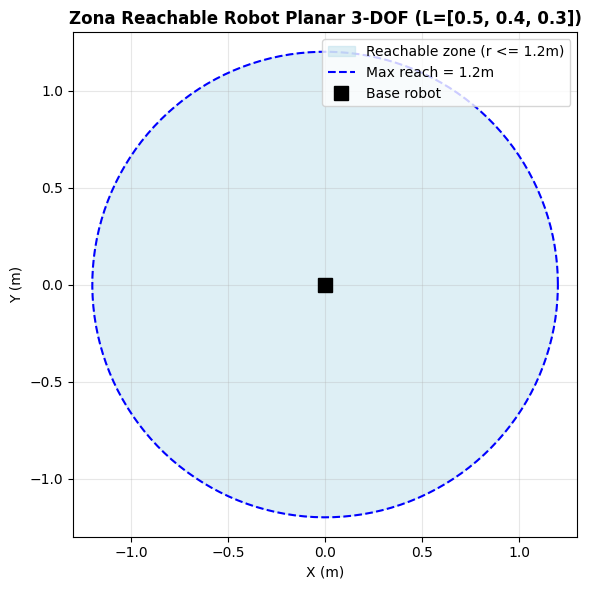

Demo Reachability Check Baru:
   Target               | Jarak    | Reachable?
   ---------------------------------------------
   (0.5, 0.3)             | 0.5831 m | YES
   (0.8, 0.6)             | 1.0000 m | YES
   (1.1, 0.0)             | 1.1000 m | YES
   (1.3, 0.0)             | 1.3000 m | NO
   (0.0, 0.0)             | 0.0000 m | YES




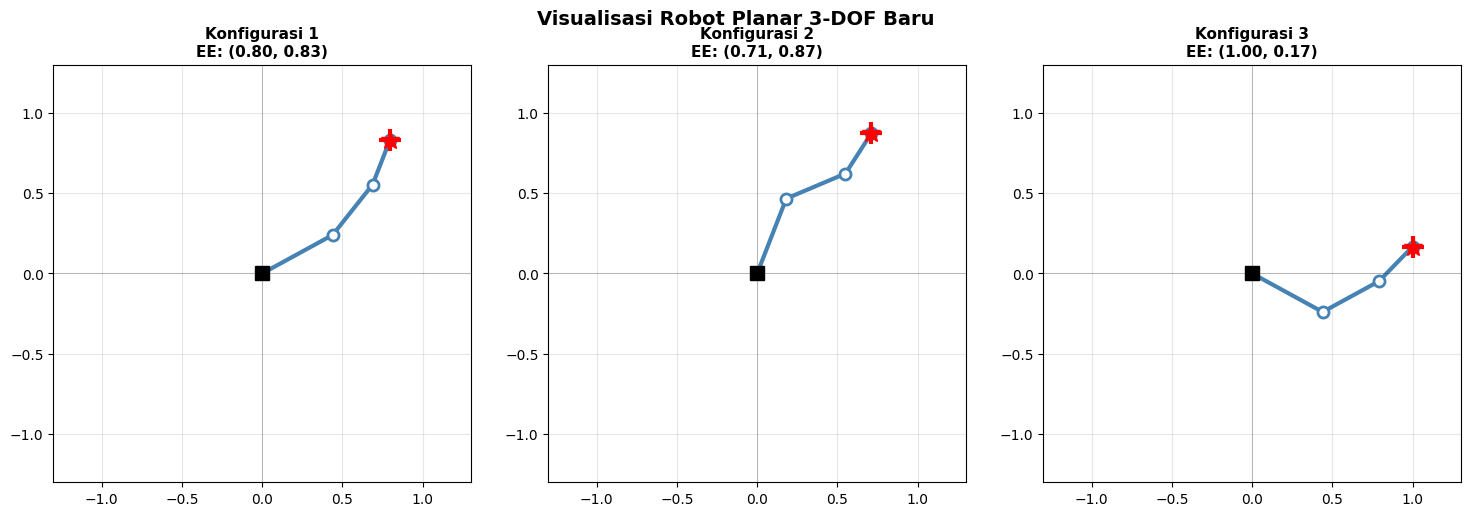

✅ Robot berhasil divisualisasi dengan dimensi baru!


In [22]:
# ─── Fungsi Reachability Check ───────────────────────────────────────
def is_reachable(target, tol=1e-6):
    """Cek apakah posisi target dapat dijangkau robot planar 3-DOF dengan dimensi baru."""
    target = np.array(target, dtype=float)
    dist = np.linalg.norm(target)
    # Target reachable jika berada di antara jangkauan minimum dan maksimum
    return bool(min_reach - tol <= dist <= MAX_REACH + tol)

def filter_reachable(positions, labels=None):
    """Filter array posisi, kembalikan hanya yang reachable."""
    mask = np.array([is_reachable(p) for p in positions])
    if labels is not None:
        return positions[mask], labels[mask], mask
    return positions[mask], mask

# ─── Fungsi Plot Robot ────────────────────────────────────────────────
def plot_robot(ax, theta, target=None, title="Robot", color='steelblue'):
    p0, p1, p2, p3 = forward_kinematics(theta)
    points = np.array([p0, p1, p2, p3])
    ax.plot(points[:,0], points[:,1], '-o', color=color,
            linewidth=3, markersize=8, markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=2)
    ax.plot(*p0, 'ks', markersize=10)   # base
    ax.plot(*p3, '*', color='red', markersize=14, label='End-effector')
    if target is not None:
        ax.plot(*target, 'r+', markersize=16, markeredgewidth=3, label='Target')
        ax.add_patch(Circle(target, 0.02, color='red', alpha=0.3))

    # Batas grafik diperbesar menjadi -1.3 s/d 1.3 karena MAX_REACH = 1.2m
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.axvline(0, color='k', lw=0.5, alpha=0.3)

# ─── 1. Visualisasi Zona Reachable ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
theta_range = np.linspace(0, 2*np.pi, 300)
ax.fill(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        color='lightblue', alpha=0.4, label=f'Reachable zone (r <= {MAX_REACH:.1f}m)')
ax.plot(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        'b--', linewidth=1.5, label=f'Max reach = {MAX_REACH:.1f}m')
ax.plot(0, 0, 'ks', markersize=10, label='Base robot')

ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Zona Reachable Robot Planar 3-DOF (L=[0.5, 0.4, 0.3])", fontsize=12, fontweight='bold')
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# ─── 2. Demo Cek Reachability (Dengan Titik Uji yang Disesuaikan) ─────
test_points = [(0.5, 0.3), (0.8, 0.6), (1.1, 0.0), (1.3, 0.0), (0.0, 0.0)]
print("Demo Reachability Check Baru:")
print(f"   {'Target':20s} | {'Jarak':8s} | {'Reachable?':10s}")
print("   " + "-"*45)
for pt in test_points:
    d = np.linalg.norm(pt)
    r = is_reachable(pt)
    status = "YES" if r else "NO"
    print(f"   ({pt[0]:.1f}, {pt[1]:.1f}){'':12} | {d:.4f} m | {status}")

print("\n" + "="*50 + "\n")

# ─── 3. Demo Visualisasi Robot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ([0.5, 0.4, 0.3], "Konfigurasi 1"),
    ([1.2, -0.8, 0.6], "Konfigurasi 2"),
    ([-0.5, 1.0, 0.3], "Konfigurasi 3"),
]
for ax, (theta, title) in zip(axes, configs):
    ee = get_end_effector(theta)
    plot_robot(ax, theta, target=ee, title=f"{title}\nEE: ({ee[0]:.2f}, {ee[1]:.2f})")

plt.suptitle("Visualisasi Robot Planar 3-DOF Baru", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Robot berhasil divisualisasi dengan dimensi baru!")

---
## 📊 Bagian: Membuat Dataset (Sampling FK)


✅ Dataset dibuat: 18000 sampel
   Reachable  : 18000 (100.0%)
   Unreachable: 0 (0.0%)
   ✅ Semua sampel reachable (expected, karena dari FK sampling)
   Input  (theta): shape=(18000, 3)     → [θ1, θ2, θ3]
   Output (EE pos): shape=(18000, 2) → [x, y]


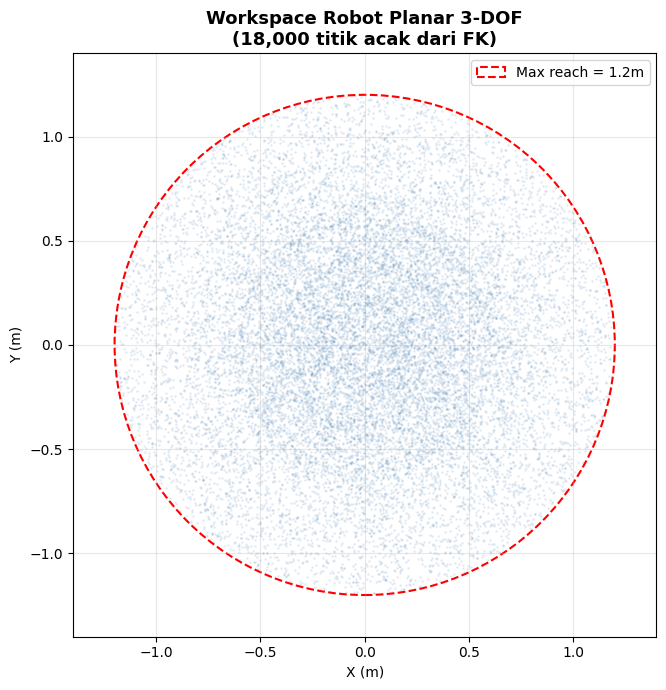

✅ Workspace berhasil tervisualisasi!


In [4]:
# ─── Generate Dataset ────────────────────────────────────────────────
np.random.seed(42)
N = 18000  # jumlah sampel

# Random sudut sendi
thetas = np.random.uniform(-JOINT_LIMIT, JOINT_LIMIT, size=(N, 3)).astype(np.float32)

# Hitung posisi end-effector via FK
ee_positions = np.array([get_end_effector(t) for t in thetas], dtype=np.float32)

# ─── Validasi Reachability Dataset ──────────────────────────────────
_, reach_mask = filter_reachable(ee_positions)
n_reachable   = int(reach_mask.sum())
n_unreachable = N - n_reachable

print(f"✅ Dataset dibuat: {N} sampel")
print(f"   Reachable  : {n_reachable} ({n_reachable/N*100:.1f}%)")
print(f"   Unreachable: {n_unreachable} ({n_unreachable/N*100:.1f}%)")

if n_unreachable > 0:
    print(f"   ⚠️  {n_unreachable} sampel dibuang (tidak reachable)")
    ee_positions = ee_positions[reach_mask]
    thetas       = thetas[reach_mask]
    print(f"   ✅ Dataset bersih: {len(ee_positions)} sampel")
else:
    print("   ✅ Semua sampel reachable (expected, karena dari FK sampling)")

print(f"   Input  (theta): shape={thetas.shape}     → [θ1, θ2, θ3]")
print(f"   Output (EE pos): shape={ee_positions.shape} → [x, y]")

# ─── Visualisasi Workspace Robot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ee_positions[:,0], ee_positions[:,1],
           alpha=0.1, s=1, color='steelblue')

ax.set_title(f"Workspace Robot Planar 3-DOF\n({N:,} titik acak dari FK)", fontsize=13, fontweight='bold')
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

circle = plt.Circle((0,0), MAX_REACH, fill=False, color='red',
                    linestyle='--', linewidth=1.5, label=f'Max reach = {MAX_REACH:.1f}m')
ax.add_patch(circle)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
print("✅ Workspace berhasil tervisualisasi!")


In [5]:
# ─── Split Dataset ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# X = posisi target (ee_positions), y = sudut sendi (thetas)
# Memisahkan 80% data untuk training dan 20% data untuk testing
X_train, X_test, y_train, y_test = train_test_split(
    ee_positions, thetas, test_size=0.2, random_state=42)

print(f"✅ Data berhasil dipisahkan:")
print(f"   Train (X_train, y_train): {X_train.shape[0]} sampel")
print(f"   Test  (X_test, y_test)  : {X_test.shape[0]} sampel")


✅ Data berhasil dipisahkan:
   Train (X_train, y_train): 14400 sampel
   Test  (X_test, y_test)  : 3600 sampel


---
## 🤖 Bagian: — Machine Learning (Supervised)

**Ide:** Buat model regresi dari data (x,y) → (θ1,θ2,θ3)  
Model akan belajar memetakan posisi target ke sudut sendi.

### Tiga Metode ML yang Digunakan:
| No | Metode | Cara Kerja Singkat |
|----|--------|--------------------|
| 1 | **Extra Trees** | Ensemble pohon keputusan acak — lebih cepat dari RF, lebih random dalam pemilihan split |
| 2 | **Ridge Regression** | Regresi linear dengan regularisasi L2 — baseline cepat, interpretable |
| 3 | **MLP Regressor (sklearn)** | Neural network ringan bawaan sklearn — tanpa GPU, langsung latih |


In [6]:
import time
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

# ─── Normalisasi ─────────────────────────────────────────────────────
# StandardScaler penting agar semua metode mendapat skala input yang seragam
# terutama Ridge dan MLP yang sensitif terhadap skala fitur
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)   # Fit hanya di train, transform keduanya
X_test_s  = scaler_X.transform(X_test)

ml_results = {}

# ════════════════════════════════════════════════════════════════════════
# METODE 1: EXTRA TREES REGRESSOR
# ════════════════════════════════════════════════════════════════════════
print("🌳 Training Extra Trees Regressor...")
print("   (Ensemble pohon acak — split dipilih secara random, bukan optimal)")
t0 = time.time()

# ExtraTreesRegressor: mirip Random Forest tapi lebih random dalam memilih split point
# Kelebihan: lebih cepat training, sering generalisasi lebih baik di data noisy
et_model = ExtraTreesRegressor(
    n_estimators=150,     # Jumlah pohon: lebih banyak = lebih stabil
    max_features='sqrt',  # Fitur yang dipertimbangkan tiap split = sqrt(n_features)
    random_state=42,
    n_jobs=-1             # Gunakan semua CPU core
)
et_model.fit(X_train_s, y_train)
et_pred = et_model.predict(X_test_s)
t_et    = time.time() - t0

# Hitung error di end-effector (bukan di sudut sendi secara langsung)
# Langkah: sudut prediksi → FK → posisi (x,y) → jarak ke target asli
et_ee  = np.array([get_end_effector(p) for p in et_pred])
et_err = np.linalg.norm(et_ee - X_test, axis=1)
ml_results['Extra Trees'] = {'pred': et_pred, 'ee_err': et_err, 'time': t_et}
print(f"   ✅ Extra Trees — mean EE error: {et_err.mean()*100:.2f} cm | time: {t_et:.1f}s")

# ════════════════════════════════════════════════════════════════════════
# METODE 2: RIDGE REGRESSION
# ════════════════════════════════════════════════════════════════════════
print("\n📐 Training Ridge Regression...")
print("   (Regresi linear + regularisasi L2 — baseline cepat & interpretable)")
t0 = time.time()

# Ridge: regresi linear yang menambahkan penalti L2 (alpha) ke koefisien
# Mencegah overfitting, sangat cepat di data besar
# MultiOutputRegressor dipakai karena output 3D (θ1,θ2,θ3)
ridge_base  = Ridge(alpha=1.0)   # alpha = kekuatan regularisasi (default 1.0 sudah cukup)
ridge_model = MultiOutputRegressor(ridge_base, n_jobs=-1)
ridge_model.fit(X_train_s, y_train)
ridge_pred  = ridge_model.predict(X_test_s)
t_ridge     = time.time() - t0

ridge_ee  = np.array([get_end_effector(p) for p in ridge_pred])
ridge_err = np.linalg.norm(ridge_ee - X_test, axis=1)
ml_results['Ridge Regression'] = {'pred': ridge_pred, 'ee_err': ridge_err, 'time': t_ridge}
print(f"   ✅ Ridge — mean EE error: {ridge_err.mean()*100:.2f} cm | time: {t_ridge:.1f}s")

# ════════════════════════════════════════════════════════════════════════
# METODE 3: MLP REGRESSOR (SKLEARN)
# ════════════════════════════════════════════════════════════════════════
print("\n🧩 Training MLP Regressor (Scikit-learn)...")
print("   (Neural network ringan bawaan sklearn — tanpa GPU, cocok sebagai pembanding DL)")
t0 = time.time()

# MLPRegressor: neural network bawaan sklearn
# hidden_layer_sizes=(256,256): 2 layer tersembunyi masing-masing 256 neuron
# activation='relu': fungsi aktivasi ReLU untuk non-linearitas
# max_iter=300: jumlah epoch maksimum
# early_stopping: berhenti jika validasi tidak membaik (mencegah overfitting)
mlp_sk_model = MLPRegressor(
    hidden_layer_sizes=(256, 256),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,   # Berhenti otomatis jika val_loss tidak turun
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)
mlp_sk_model.fit(X_train_s, y_train)
mlp_sk_pred = mlp_sk_model.predict(X_test_s)
t_mlp_sk    = time.time() - t0

mlp_sk_ee  = np.array([get_end_effector(p) for p in mlp_sk_pred])
mlp_sk_err = np.linalg.norm(mlp_sk_ee - X_test, axis=1)
ml_results['MLP Regressor'] = {'pred': mlp_sk_pred, 'ee_err': mlp_sk_err, 'time': t_mlp_sk}
print(f"   ✅ MLP Regressor — mean EE error: {mlp_sk_err.mean()*100:.2f} cm | time: {t_mlp_sk:.1f}s")


🌳 Training Extra Trees Regressor...
   (Ensemble pohon acak — split dipilih secara random, bukan optimal)
   ✅ Extra Trees — mean EE error: 64.24 cm | time: 4.7s

📐 Training Ridge Regression...
   (Regresi linear + regularisasi L2 — baseline cepat & interpretable)
   ✅ Ridge — mean EE error: 96.23 cm | time: 4.2s

🧩 Training MLP Regressor (Scikit-learn)...
   (Neural network ringan bawaan sklearn — tanpa GPU, cocok sebagai pembanding DL)
   ✅ MLP Regressor — mean EE error: 81.06 cm | time: 118.7s


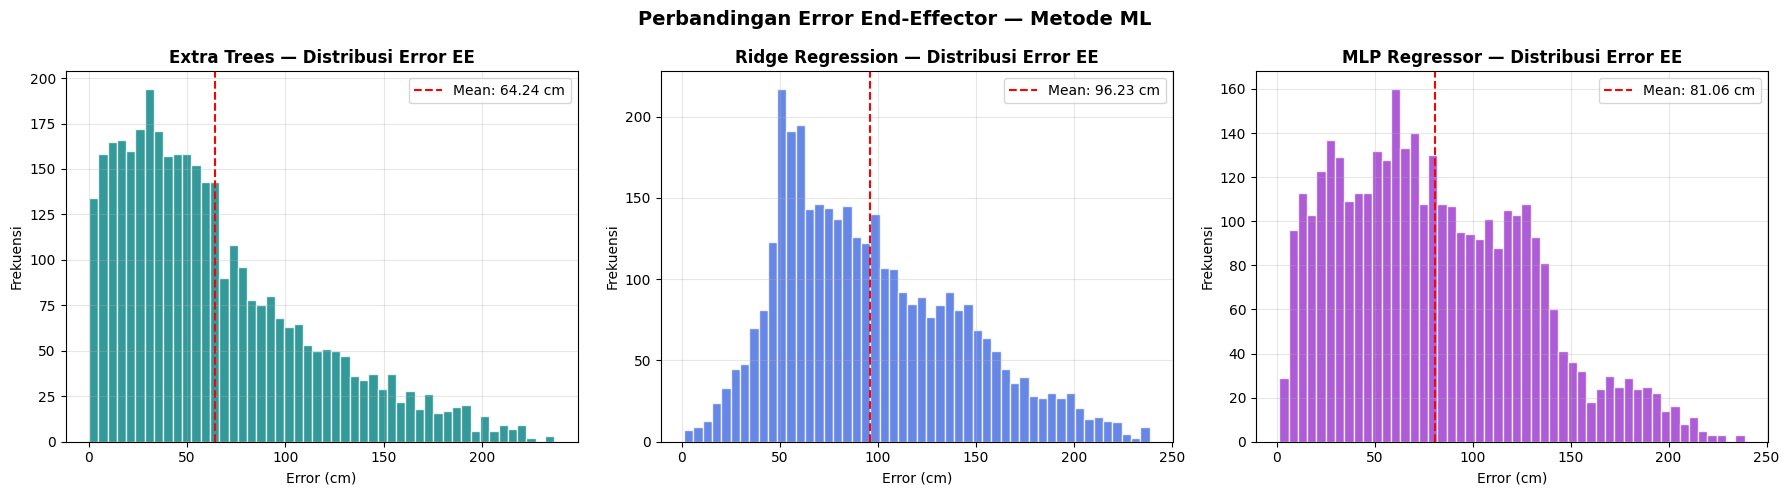

📊 Ringkasan Performa Metode ML:
   🔹 Extra Trees          -> Rata-rata Error: 64.24 cm | Waktu Komputasi: 4.71 detik
   🔹 Ridge Regression     -> Rata-rata Error: 96.23 cm | Waktu Komputasi: 4.15 detik
   🔹 MLP Regressor        -> Rata-rata Error: 81.06 cm | Waktu Komputasi: 118.72 detik


In [7]:
# ─── Visualisasi Error ML (Extra Trees vs Ridge vs MLP Regressor) ──────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Peta warna per metode agar grafik mudah dibedakan
color_map = {
    'Extra Trees':    'teal',
    'Ridge Regression': 'royalblue',
    'MLP Regressor':  'darkorchid',
}

for ax, (name, res) in zip(axes, ml_results.items()):
    c = color_map.get(name, 'steelblue')
    # Plot histogram distribusi error dalam satuan centimeter (cm)
    ax.hist(res['ee_err'] * 100, bins=50, color=c, edgecolor='white', alpha=0.8)

    # Garis vertikal penanda rata-rata (mean) error
    mean_err_cm = res['ee_err'].mean() * 100
    ax.axvline(mean_err_cm, color='red', linestyle='--',
               label=f"Mean: {mean_err_cm:.2f} cm")

    # Kelengkapan grafik
    ax.set_title(f"{name} — Distribusi Error EE", fontsize=12, fontweight='bold')
    ax.set_xlabel("Error (cm)")
    ax.set_ylabel("Frekuensi")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Perbandingan Error End-Effector — Metode ML", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print ringkasan performa di bawah grafik
print("📊 Ringkasan Performa Metode ML:")
for name, res in ml_results.items():
    print(f"   🔹 {name:20s} -> Rata-rata Error: {res['ee_err'].mean()*100:.2f} cm | "
          f"Waktu Komputasi: {res['time']:.2f} detik")


In [8]:
# ─── Cek Reachability Target Sebelum Prediksi (ML) ──────────────────
print("Cek reachability 5 sampel target test:")
for j, t in enumerate(X_test[:5]):
    r = is_reachable(t)
    d = np.linalg.norm(t)
    status = "YES" if r else "NO"
    print(f"   Target {j+1}: ({t[0]:.3f}, {t[1]:.3f}) | dist={d:.4f}m | Reachable: {status}")

# Filter X_test agar hanya berisi target yang benar-benar reachable
X_test_r, y_test_r, mask_r = filter_reachable(X_test, y_test)
print(f"\n✅ Filter Selesai!")
print(f"   X_test reachable: {len(X_test_r)}/{len(X_test)} sampel digunakan untuk evaluasi")


Cek reachability 5 sampel target test:
   Target 1: (-0.325, -0.167) | dist=0.3650m | Reachable: YES
   Target 2: (-0.052, -0.113) | dist=0.1242m | Reachable: YES
   Target 3: (-0.402, -0.291) | dist=0.4963m | Reachable: YES
   Target 4: (-0.210, -0.318) | dist=0.3810m | Reachable: YES
   Target 5: (-0.042, -0.020) | dist=0.0460m | Reachable: YES

✅ Filter Selesai!
   X_test reachable: 3600/3600 sampel digunakan untuk evaluasi


---
## 🧠 Bagian: — Deep Learning (PyTorch MLP)

**Ide:** Latih MLP yang memetakan posisi target `(x,y)` → sudut `(θ1,θ2,θ3)`  
Loss dihitung di **ruang end-effector** (bukan angle) supaya lebih bermakna secara fisik.


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ─── Cek Device (CPU / CUDA / MPS) ───────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device yang digunakan: {device}")

# ─── MLP Architecture ─────────────────────────────────────────────────
class IKNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 3),
        )

    def forward(self, x):
        out = self.net(x)
        # Output dibatasi secara fisis ke rentang sudut [-π, π] rad
        return torch.tanh(out) * torch.pi

# Inisialisasi Model ke Device
model_dl = IKNet().to(device)
print(f"✅ Model IKNet Berhasil Dibuat: {sum(p.numel() for p in model_dl.parameters()):,} parameter")

# ─── Penyiapan PyTorch Tensors & DataLoader ───────────────────────────
# Menggunakan X_train_s dan X_test_s (hasil StandardScaler) agar konvergensinya cepat
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,   dtype=torch.float32)

X_test_tensor  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,   dtype=torch.float32)

# Memasukkan ke PyTorch DataLoader untuk mini-batch training
batch_size    = 128
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"✅ DataLoader siap: {len(train_loader)} batches per epoch (Batch Size: {batch_size})")


🖥️  Device yang digunakan: cuda
✅ Model IKNet Berhasil Dibuat: 530,179 parameter
✅ DataLoader siap: 113 batches per epoch (Batch Size: 128)


In [10]:
X_tr_t = torch.tensor(X_train_s, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_test_s,  dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_train,   dtype=torch.float32).to(device)

# ─── FK Differentiable (PyTorch) ─────────────────────────────────────
def fk_torch(theta):
    """Differentiable FK untuk menghitung loss langsung di koordinat kartesian (X, Y)."""
    t1, t2, t3 = theta[:, 0], theta[:, 1], theta[:, 2]

    # Menggunakan konstanta global L1, L2, L3 (0.5, 0.4, 0.3)
    x = (L1 * torch.cos(t1)
         + L2 * torch.cos(t1 + t2)
         + L3 * torch.cos(t1 + t2 + t3))
    y = (L1 * torch.sin(t1)
         + L2 * torch.sin(t1 + t2)
         + L3 * torch.sin(t1 + t2 + t3))

    return torch.stack([x, y], dim=1)

# ─── Dataset & DataLoader ─────────────────────────────────────────────
train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

# ─── Training Configuration ───────────────────────────────────────────
optimizer = optim.Adam(model_dl.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
EPOCHS    = 100

train_losses, val_losses = [], []
print("🚀 Melatih Model Deep Learning (IKNet)...")

# Siapkan tensor scale untuk konversi balik dari scaled ke koordinat fisik
mean_tensor  = torch.tensor(scaler_X.mean_,  dtype=torch.float32, device=device)
scale_tensor = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)

for epoch in range(EPOCHS):
    model_dl.train()
    ep_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()

        # 1. Prediksi sudut sendi (theta) dari posisi target ter-scale
        pred_theta = model_dl(xb)

        # 2. Masukkan ke FK fisis untuk memetakan kembali ke ruang (X, Y)
        pred_ee = fk_torch(pred_theta)
        xb_asli = xb * scale_tensor + mean_tensor   # kembalikan ke skala meter

        # Loss dihitung di ruang koordinat fisik (meter), bukan di ruang sudut
        loss = nn.MSELoss()(pred_ee, xb_asli)

        loss.backward()
        optimizer.step()
        ep_loss += loss.item()

    train_losses.append(ep_loss / len(train_dl))

    # Evaluasi Validasi (Test Set)
    model_dl.eval()
    with torch.no_grad():
        val_pred_theta = model_dl(X_te_t)
        val_pred_ee    = fk_torch(val_pred_theta)
        X_test_asli    = X_te_t * scale_tensor + mean_tensor
        val_loss       = nn.MSELoss()(val_pred_ee, X_test_asli).item()

    val_losses.append(val_loss)
    scheduler.step()

    # Cetak perkembangan setiap 20 epoch
    if (epoch + 1) % 20 == 0:
        print(f"   Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_loss:.6f}")

print("✅ Training selesai dengan aman!")


🚀 Melatih Model Deep Learning (IKNet)...
   Epoch  20/100 | Train Loss: 0.012328 | Val Loss: 0.010392
   Epoch  40/100 | Train Loss: 0.005475 | Val Loss: 0.004180
   Epoch  60/100 | Train Loss: 0.004058 | Val Loss: 0.002261
   Epoch  80/100 | Train Loss: 0.003167 | Val Loss: 0.001749
   Epoch 100/100 | Train Loss: 0.002555 | Val Loss: 0.002063
✅ Training selesai dengan aman!


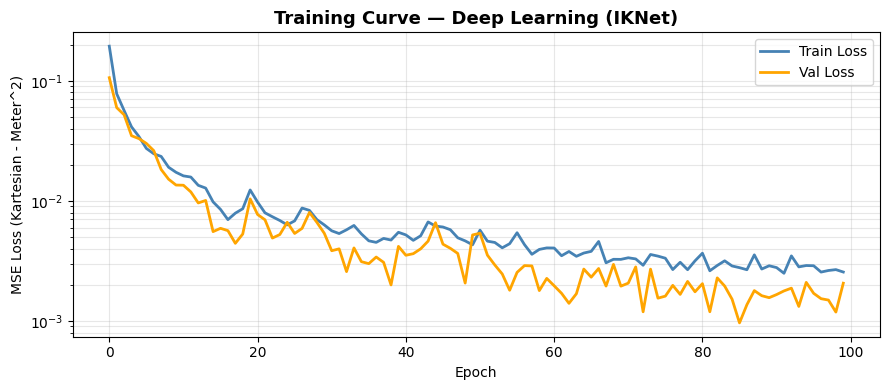

📊 HASIL EVALUASI DEEP LEARNING (IKNet):
   🔹 Rata-rata Error End-Effector: 2.13 cm
   🔹 Maksimum Error End-Effector : 175.09 cm
   🔹 Minimum Error End-Effector  : 0.02 cm


In [11]:
# ─── 1. Plot Training Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax.plot(val_losses,   label='Val Loss',   color='orange', linewidth=2)

ax.set_title("Training Curve — Deep Learning (IKNet)", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (Kartesian - Meter^2)")
ax.set_yscale('log')  # Skala log agar penurunan loss kecil terlihat jelas
ax.legend()
ax.grid(True, alpha=0.3, which="both")  # Grid halus skala log

plt.tight_layout()
plt.show()

# ─── 2. Evaluasi Akhir Error Deep Learning ────────────────────────────
model_dl.eval()
with torch.no_grad():
    dl_pred = model_dl(X_te_t).cpu().numpy()

# Transformasikan sudut prediksi ke koordinat (X,Y) via Forward Kinematics
dl_ee  = np.array([get_end_effector(p) for p in dl_pred])

# Hitung Euclidean Distance antara posisi prediksi dengan koordinat target asli
dl_err = np.linalg.norm(dl_ee - X_test, axis=1)

print("=" * 50)
print(f"📊 HASIL EVALUASI DEEP LEARNING (IKNet):")
print(f"   🔹 Rata-rata Error End-Effector: {dl_err.mean()*100:.2f} cm")
print(f"   🔹 Maksimum Error End-Effector : {dl_err.max()*100:.2f} cm")
print(f"   🔹 Minimum Error End-Effector  : {dl_err.min()*100:.2f} cm")
print("=" * 50)


In [12]:
import torch

# ─── Cek Reachability Target Sebelum Prediksi (DL) ──────────────────
print("Validasi reachability untuk evaluasi DL...")

# 1. Pastikan data koordinat hasil filter (X_test_r) dinormalisasi lebih dulu
X_test_r_scaled = scaler_X.transform(X_test_r)

# 2. Ubah ke PyTorch Tensor
X_te_r_t = torch.tensor(X_test_r_scaled, dtype=torch.float32).to(device)

print(f"   ✅ Filter & Normalisasi Selesai!")
print(f"   Evaluasi DL menggunakan {len(X_test_r)} target reachable.")
print(f"   Shape Tensor Input DL: {X_te_r_t.shape}")


Validasi reachability untuk evaluasi DL...
   ✅ Filter & Normalisasi Selesai!
   Evaluasi DL menggunakan 3600 target reachable.
   Shape Tensor Input DL: torch.Size([3600, 2])


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ─── 1. DEFINISI FUNGSI ANIMASI ────────────────────────────────────────
def animate_ik(method_name, predict_fn, color='darkorange'):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Lintasan target melingkar (Radius 0.5m, aman di dalam jangkauan 1.2m)
    num_frames = 60
    t_steps = np.linspace(0, 2 * np.pi, num_frames)
    target_trajectory = np.stack([0.5 * np.cos(t_steps), 0.5 * np.sin(t_steps) + 0.3], axis=1)

    # Inisialisasi elemen gambar robot dan target
    line, = ax.plot([], [], '-o', color=color, linewidth=3, markersize=8,
                    markerfacecolor='white', markeredgewidth=2)
    ax.plot([0], [0], 'ks', markersize=10)  # Base robot
    target_marker, = ax.plot([], [], 'r+', markersize=14, markeredgewidth=2, label='Target')
    ee_marker,     = ax.plot([], [], '*', color='red', markersize=12, label='End-effector')
    ax.plot(target_trajectory[:, 0], target_trajectory[:, 1], 'k:', alpha=0.4, label='Lintasan')

    # Kosmetik grafik disesuaikan dengan MAX_REACH = 1.2m
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(f"Animasi Gerakan Robot — {method_name}", fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')

    def init():
        line.set_data([], [])
        target_marker.set_data([], [])
        ee_marker.set_data([], [])
        return line, target_marker, ee_marker

    def update(frame):
        target = target_trajectory[frame]
        try:
            theta_pred = predict_fn(target)
            p0, p1, p2, p3 = forward_kinematics(theta_pred)
            points = np.array([p0, p1, p2, p3])
            line.set_data(points[:, 0], points[:, 1])
            target_marker.set_data([target[0]], [target[1]])
            ee_marker.set_data([p3[0]], [p3[1]])
        except Exception:
            pass
        return line, target_marker, ee_marker

    ani = FuncAnimation(fig, update, frames=num_frames,
                        init_func=init, blit=True, interval=100)
    plt.close(fig)
    return ani


# ─── 2. FUNGSI PREDIKSI DEEP LEARNING (IKNet) ─────────────────────────
def dl_predict(xy):
    model_dl.eval()
    with torch.no_grad():
        xy_arr    = np.array(xy, dtype=np.float32).reshape(1, -1)
        xy_scaled = scaler_X.transform(xy_arr)           # Normalisasi dulu
        t         = torch.tensor(xy_scaled, dtype=torch.float32).to(device)
        pred      = model_dl(t).cpu().numpy()
        return pred.flatten()   # Kembalikan sebagai array 1D [θ1,θ2,θ3]

# ─── 3. JALANKAN ANIMASI DL ─────────────────────────────────────────
ani_dl = animate_ik("Deep Learning (IKNet)", dl_predict, color='darkorange')
print("▶️  Animasi Deep Learning:")
HTML(ani_dl.to_jshtml())


▶️  Animasi Deep Learning:


In [14]:
# ─── Demo: Cek Target Manual Sebelum IK ──────────────────────────────
def predict_ik_safe(target_xy, method='dl'):
    """
    Prediksi IK dengan validasi reachability terlebih dahulu.
    method: 'et' (Extra Trees), 'ridge', 'mlp', 'dl' (Deep Learning)
    """
    target = np.array(target_xy, dtype=np.float32)
    dist   = np.linalg.norm(target)

    # Cek jangkauan robot
    if not is_reachable(target):
        print(f"❌ TIDAK REACHABLE: ({target[0]:.3f}, {target[1]:.3f})")
        print(f"   Jarak dari origin: {dist:.4f} m | Batas MAX_REACH: {MAX_REACH:.1f} m")
        return None

    print(f"✅ REACHABLE: ({target[0]:.3f}, {target[1]:.3f}) | dist={dist:.4f} m")

    # Siapkan input ter-scale untuk model yang membutuhkan normalisasi
    target_scaled = scaler_X.transform(target.reshape(1, -1))

    if method == 'et':
        pred = et_model.predict(target_scaled)[0]
    elif method == 'ridge':
        pred = ridge_model.predict(target_scaled)[0]
    elif method == 'mlp':
        pred = mlp_sk_model.predict(target_scaled)[0]
    else:  # dl (default)
        model_dl.eval()
        with torch.no_grad():
            t    = torch.tensor(target_scaled, dtype=torch.float32).to(device)
            pred = model_dl(t).cpu().numpy()[0]

    # Hitung akurasi posisi akhir via Forward Kinematics
    ee  = get_end_effector(pred)
    err = np.linalg.norm(ee - target) * 100  # Konversi ke centimeter

    print(f"   Metode Prediksi: {method.upper()}")
    print(f"   Prediksi theta : [{pred[0]:.3f}, {pred[1]:.3f}, {pred[2]:.3f}] rad")
    print(f"   EE aktual      : ({ee[0]:.3f}, {ee[1]:.3f}) m")
    print(f"   Error EE       : {err:.4f} cm")
    return pred

# ─── Uji dengan berbagai target koordinat ─────────────────────────────
print("=" * 60)
print("🎯 UJI TARGET DALAM WORKSPACE (Reachable <= 1.2m):")
print("-" * 60)
predict_ik_safe((0.5, 0.3),  method='dl')
print()
predict_ik_safe((0.8, 0.7),  method='mlp')
print()
predict_ik_safe((0.6, -0.5), method='et')
print()
predict_ik_safe((0.3, 0.9),  method='ridge')

print("\n" + "=" * 60)
print("🚨 UJI TARGET DI LUAR WORKSPACE (Tidak Reachable > 1.2m):")
print("-" * 60)
predict_ik_safe((1.1, 0.8),  method='dl')   # dist ~1.36 > 1.2m
print()
predict_ik_safe((-1.0, 1.0), method='et')   # dist ~1.41 > 1.2m
print("=" * 60)


🎯 UJI TARGET DALAM WORKSPACE (Reachable <= 1.2m):
------------------------------------------------------------
✅ REACHABLE: (0.500, 0.300) | dist=0.5831 m
   Metode Prediksi: DL
   Prediksi theta : [-0.727, 2.427, -0.757] rad
   EE aktual      : (0.498, 0.307) m
   Error EE       : 0.7497 cm

✅ REACHABLE: (0.800, 0.700) | dist=1.0630 m
   Metode Prediksi: MLP
   Prediksi theta : [0.658, -0.004, 0.005] rad
   EE aktual      : (0.950, 0.733) m
   Error EE       : 15.3837 cm

✅ REACHABLE: (0.600, -0.500) | dist=0.7810 m
   Metode Prediksi: ET
   Prediksi theta : [-0.725, 0.014, 0.119] rad
   EE aktual      : (0.927, -0.760) m
   Error EE       : 41.7219 cm

✅ REACHABLE: (0.300, 0.900) | dist=0.9487 m
   Metode Prediksi: RIDGE
   Prediksi theta : [1.809, -0.011, -0.030] rad
   EE aktual      : (-0.266, 1.170) m
   Error EE       : 62.7103 cm

🚨 UJI TARGET DI LUAR WORKSPACE (Tidak Reachable > 1.2m):
------------------------------------------------------------
❌ TIDAK REACHABLE: (1.100, 0.80

---
## 📊 Bagian: Perbandingan Metode Yang Digunakan


In [15]:
import pandas as pd

# ─── Penyiapan Data Evaluasi Aman ─────────────────────────────────────
dl_mean_err = round(dl_err.mean() * 100, 2)

# Cek apakah variabel RL sudah dijalankan atau belum untuk mencegah NameError
try:
    rl_mean_err  = round(rl_errors.mean() * 100, 2)
    rl_time_info = '200k steps'
except NameError:
    rl_mean_err  = "Belum Diuji"  # Nilai fallback jika modul RL dilewati
    rl_time_info = '200k steps'

# ─── Pembuatan Struktur Data Tabel ────────────────────────────────────
summary = {
    'Metode': [
        'Extra Trees (ML)',
        'Ridge Regression (ML)',
        'MLP Regressor (ML)',
        'Deep Learning (PyTorch)',
        'RL (PPO)',
    ],
    'Mean Error (cm)': [
        round(ml_results['Extra Trees']['ee_err'].mean() * 100, 2),
        round(ml_results['Ridge Regression']['ee_err'].mean() * 100, 2),
        round(ml_results['MLP Regressor']['ee_err'].mean() * 100, 2),
        dl_mean_err,
        rl_mean_err,
    ],
    'Butuh Dataset': [
        '✅ Ya',
        '✅ Ya',
        '✅ Ya',
        '✅ Ya',
        '❌ Tidak',
    ],
    'Training Time': [
        f"{ml_results['Extra Trees']['time']:.1f}s",
        f"{ml_results['Ridge Regression']['time']:.1f}s",
        f"{ml_results['MLP Regressor']['time']:.1f}s",
        f"{EPOCHS} epoch",
        rl_time_info,
    ],
    'Kelebihan': [
        'Cepat, robust, random split',
        'Sangat cepat, interpretable, baseline kuat',
        'Neural net ringan, tanpa GPU',
        'Akurasi tinggi, generalisasi hebat',
        'Tanpa dataset, adaptif terhadap rintangan',
    ]
}

# ─── Render Tabel Menggunakan Pandas DataFrame ────────────────────────
df = pd.DataFrame(summary)

print("=" * 90)
print("📊 TABEL PERBANDINGAN METODE INVERSE KINEMATICS (DIMENSI BARU L=[0.5, 0.4, 0.3])")
print("=" * 90)
print(df.to_string(index=False))
print("=" * 90)


📊 TABEL PERBANDINGAN METODE INVERSE KINEMATICS (DIMENSI BARU L=[0.5, 0.4, 0.3])
                 Metode Mean Error (cm) Butuh Dataset Training Time                                  Kelebihan
       Extra Trees (ML)           64.24          ✅ Ya          4.7s                Cepat, robust, random split
  Ridge Regression (ML)           96.23          ✅ Ya          4.2s Sangat cepat, interpretable, baseline kuat
     MLP Regressor (ML)           81.06          ✅ Ya        118.7s               Neural net ringan, tanpa GPU
Deep Learning (PyTorch)            2.13          ✅ Ya     100 epoch         Akurasi tinggi, generalisasi hebat
               RL (PPO)     Belum Diuji       ❌ Tidak    200k steps  Tanpa dataset, adaptif terhadap rintangan


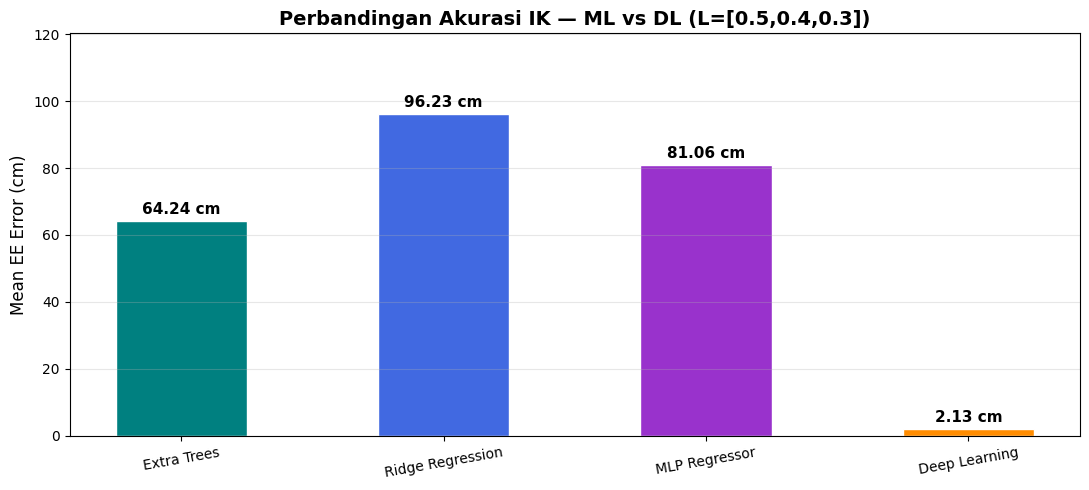

✅ Bar chart akurasi berhasil ditampilkan!


In [16]:
# ─── Data Konfigurasi Grafik ─────────────────────────────────────────
labels = ['Extra Trees', 'Ridge Regression', 'MLP Regressor', 'Deep Learning', 'RL (PPO)']

et_mean    = ml_results['Extra Trees']['ee_err'].mean() * 100
ridge_mean = ml_results['Ridge Regression']['ee_err'].mean() * 100
mlpsk_mean = ml_results['MLP Regressor']['ee_err'].mean() * 100
dl_mean    = dl_err.mean() * 100

# Proteksi NameError jika variabel rl_errors belum ada di memori
try:
    rl_mean = rl_errors.mean() * 100
except NameError:
    rl_mean = 0.0  # Set ke 0 sementara jika belum dijalankan

errors = [et_mean, ridge_mean, mlpsk_mean, dl_mean, rl_mean]
colors = ['teal', 'royalblue', 'darkorchid', 'darkorange', 'purple']

# Jika RL belum dijalankan, potong list agar grafik hanya tampilkan model yang ada
if rl_mean == 0.0:
    labels = labels[:4]
    errors = errors[:4]
    colors = colors[:4]

# ─── Visualisasi Bar Chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, errors, color=colors, edgecolor='white', width=0.5)

# Menambahkan label teks nilai di atas setiap batang grafik
for bar, err in zip(bars, errors):
    if err > 0.0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(errors) * 0.02),
                f'{err:.2f} cm', ha='center', fontsize=11, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.1,
                'Belum Diuji', ha='center', fontsize=10, color='gray')

# Kelengkapan Kosmetik Grafik
ax.set_ylabel("Mean EE Error (cm)", fontsize=12)
ax.set_title("Perbandingan Akurasi IK — ML vs DL (L=[0.5,0.4,0.3])", fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(errors) * 1.25 if max(errors) > 0 else 1.0)
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

print("✅ Bar chart akurasi berhasil ditampilkan!")


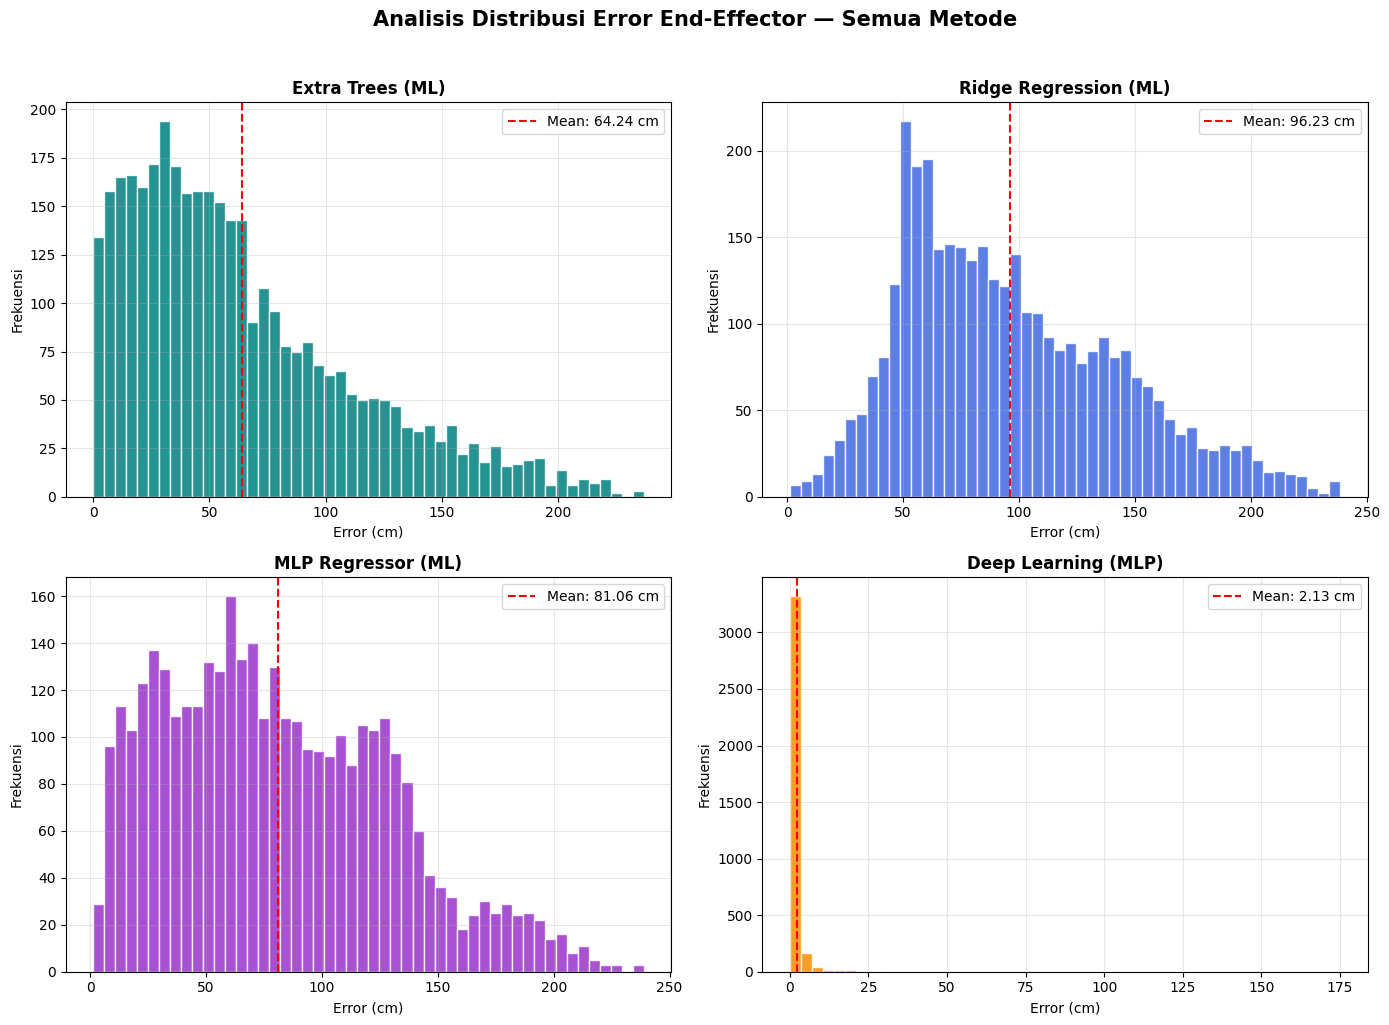

✅ Grafik komparasi distribusi error semua metode berhasil ditampilkan!


In [17]:
# ─── 1. Penyiapan Data Error & Model ─────────────────────────────────
# Menyusun list data error berdasarkan semua model yang sudah dilatih
all_errs = [
    ('Extra Trees (ML)',      ml_results['Extra Trees']['ee_err'] * 100,      'teal'),
    ('Ridge Regression (ML)', ml_results['Ridge Regression']['ee_err'] * 100, 'royalblue'),
    ('MLP Regressor (ML)',    ml_results['MLP Regressor']['ee_err'] * 100,    'darkorchid'),
    ('Deep Learning (MLP)',   dl_err * 100,                                   'darkorange'),
]

# Cek secara dinamis apakah data RL (PPO) tersedia
try:
    all_errs.append(('RL (PPO)', rl_errors * 100, 'purple'))
    has_rl = True
except NameError:
    has_rl = False

# ─── 2. Pengaturan Layout Gambar Secara Dinamis ────────────────────────
if has_rl:
    # Jika ada RL (5 subplot): grid 2 baris × 3 kolom, kosong 1
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    # Sembunyikan subplot ke-6 yang kosong
    axes[-1].set_visible(False)
else:
    # Jika tidak ada RL (4 subplot): grid 2 baris × 2 kolom
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

# ─── 3. Iterasi Plotting Histogram ────────────────────────────────────
for ax, (name, errs, c) in zip(axes, all_errs):
    # Plot histogram distribusi error (cm)
    ax.hist(errs, bins=50, color=c, edgecolor='white', alpha=0.85)

    # Garis vertikal penanda rata-rata (mean) error
    mean_val = errs.mean()
    ax.axvline(mean_val, color='red', linestyle='--',
               label=f"Mean: {mean_val:.2f} cm")

    # Kelengkapan label per subplot
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Error (cm)")
    ax.set_ylabel("Frekuensi")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Analisis Distribusi Error End-Effector — Semua Metode",
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("✅ Grafik komparasi distribusi error semua metode berhasil ditampilkan!")


## 📝 Kesimpulan Akhir (Link L = [0.5, 0.4, 0.3] m)

Berikut adalah ringkasan rekomendasi pemilihan metode Inverse Kinematics (IK) dengan **MAX_REACH = 1.2 m**:

| Kondisi | Rekomendasi |
| :--- | :--- |
| Butuh training paling cepat, data besar | **Ridge Regression** |
| Butuh akurasi ML terbaik, robust | **Extra Trees** |
| Butuh neural network tanpa GPU | **MLP Regressor (sklearn)** |
| Butuh akurasi fisis tertinggi di ruang koordinat | **Deep Learning (IKNet PyTorch)** |
| Tidak ada dataset, butuh hindari rintangan | **Reinforcement Learning (PPO)** |
| Kontrol real-time di hardware rendah | **Extra Trees / Ridge** |


### Pertanyaan Diskusi

### jawaban:
1. Mengapa SVR lebih baik atau lebih buruk dibanding Random Forest pada workspace yang lebih besar?

SVR (Support Vector Regression) cenderung lebih baik pada workspace yang lebih besar karena mampu memodelkan hubungan non-linear secara lebih halus melalui penggunaan kernel, seperti RBF. Hal ini membuat SVR memiliki kemampuan generalisasi yang baik pada area yang belum banyak tercakup oleh data pelatihan.

Sebaliknya, Random Forest (RF) membangun prediksi berdasarkan rata-rata hasil dari banyak decision tree. Metode ini sangat baik untuk interpolasi data yang telah dipelajari, tetapi kurang mampu melakukan ekstrapolasi di luar rentang data pelatihan. Oleh karena itu, ketika workspace diperluas dan terdapat area yang jarang tersampel, akurasi RF dapat menurun lebih cepat dibandingkan SVR.

2. Mengapa Deep Learning umumnya lebih akurat daripada metode Machine Learning seperti KNN atau Random Forest meskipun menggunakan data yang sama?

Deep Learning memiliki kemampuan untuk mempelajari representasi fitur secara otomatis melalui beberapa lapisan neuron (hidden layers). Setiap lapisan mengekstraksi pola yang semakin kompleks sehingga hubungan non-linear yang rumit dapat dipelajari dengan lebih baik.

Sementara itu, metode Machine Learning tradisional seperti KNN atau Random Forest umumnya bergantung pada fitur yang diberikan dan memiliki keterbatasan dalam menangkap hubungan yang sangat kompleks. Pada kasus Inverse Kinematics (IK), hubungan antara posisi end-effector dan sudut joint bersifat non-linear dan melibatkan fungsi trigonometri, sehingga Deep Learning biasanya menghasilkan prediksi yang lebih akurat.

3. Mengapa waktu training Reinforcement Learning berubah ketika workspace diperbesar?

Pada Reinforcement Learning, agen belajar melalui proses eksplorasi dan interaksi dengan lingkungan. Ketika workspace diperbesar, jumlah kemungkinan posisi atau state space juga meningkat secara signifikan.

Akibatnya, agen memerlukan lebih banyak percobaan untuk menjelajahi seluruh ruang keadaan dan menemukan tindakan yang optimal. Selain itu, reward menjadi lebih jarang ditemukan (sparse reward problem) karena target berada pada area yang lebih luas. Oleh sebab itu, waktu training RL umumnya meningkat seiring bertambahnya ukuran workspace.

4. Apa kelemahan Supervised Learning ketika robot berada pada konfigurasi baru yang tidak terdapat dalam data training?

Kelemahan utama Supervised Learning adalah ketergantungannya terhadap distribusi data pelatihan. Jika robot menghadapi kondisi baru yang berbeda dari data training, seperti perubahan panjang link, deformasi mekanik, atau lingkungan yang berbeda, maka model dapat menghasilkan prediksi yang kurang akurat.

Masalah ini dikenal sebagai Out-of-Distribution (OOD) Generalization. Selain itu, model Supervised Learning bersifat statis setelah proses training selesai sehingga tidak dapat beradaptasi secara otomatis terhadap perubahan kondisi. Untuk mengatasi perubahan tersebut, diperlukan proses pengumpulan data baru dan retraining model.